# Прогноз цены акций Сбербанка (SBER)

## Установка библиотек

In [20]:
!pip install prophet pandas numpy matplotlib scikit-learn mlflow requests -q
!pip install boto3

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


Defaulting to user installation because normal site-packages is not writeable


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import json
import pickle
import os
from datetime import datetime, timedelta
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from prophet import Prophet
import pickle
from itertools import product
import mlflow.pyfunc

In [22]:
import warnings
warnings.filterwarnings('ignore')


In [23]:
!pip install cmdstanpy==0.9.68

Defaulting to user installation because normal site-packages is not writeable
  Using cached cmdstanpy-0.9.68-py3-none-any.whl.metadata (3.7 kB)
Using cached cmdstanpy-0.9.68-py3-none-any.whl (49 kB)
  Attempting uninstall: cmdstanpy
    Found existing installation: cmdstanpy 1.3.0
    Uninstalling cmdstanpy-1.3.0:
      Successfully uninstalled cmdstanpy-1.3.0


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
prophet 1.1.6 requires cmdstanpy>=1.0.4, but you have cmdstanpy 0.9.68 which is incompatible.


## Загрузка (ISS API Мосбиржи)

In [24]:

def load_moex_daily(ticker, start_date, end_date):
    url = f"https://iss.moex.com/iss/engines/stock/markets/shares/securities/{ticker}/candles.json"
    
    all_data = []
    current_start = start_date
    
    while current_start < end_date:
        current_end = min(current_start + timedelta(days=180), end_date)
        
        params = {
            'from': current_start.strftime('%Y-%m-%d'),
            'till': current_end.strftime('%Y-%m-%d'),
            'interval': 24,
            'iss.meta': 'off'
        }
        
        print(f"Загружаем {ticker} с {current_start.date()} по {current_end.date()}...")
        
        try:
            response = requests.get(url, params=params, timeout=30)
            response.raise_for_status()
            data = response.json()
            
            candles = data['candles']
            columns = candles['columns']
            rows = candles['data']
            
            if rows:
                df_chunk = pd.DataFrame(rows, columns=columns)
                all_data.append(df_chunk)
                print(f"Получено строк: {len(df_chunk)}")
            else:
                print(f"Нет данных за этот период")
        
        except Exception as e:
            print(f"Ошибка: {e}")
        
        current_start = current_end + timedelta(days=1)
    
    if all_data:
        df = pd.concat(all_data, ignore_index=True)
        df = df.drop_duplicates(subset=['begin']).sort_values('begin').reset_index(drop=True)
        return df
    else:
        return pd.DataFrame()



In [25]:
# Загружаем 3 года дневных данных
TICKER = 'SBER'
END_DATE = datetime.today()
START_DATE = END_DATE - timedelta(days=3*365)

print(f"Загружаем 3 года дневных данных по {TICKER} через ISS API...")
print(f"Период: {START_DATE.date()} — {END_DATE.date()}\n")

df_iss = load_moex_daily(TICKER, START_DATE, END_DATE)

print(f"\n Загружено строк: {len(df_iss)}")
if not df_iss.empty:
    print(f"Диапазон: {df_iss['begin'].min()} — {df_iss['begin'].max()}")
    display(df_iss.head())

Загружаем 3 года дневных данных по SBER через ISS API...
Период: 2023-07-02 — 2026-07-01

Загружаем SBER с 2023-07-02 по 2023-12-29...
Получено строк: 130
Загружаем SBER с 2023-12-30 по 2024-06-27...
Получено строк: 123
Загружаем SBER с 2024-06-28 по 2024-12-25...
Получено строк: 129
Загружаем SBER с 2024-12-26 по 2025-06-24...
Получено строк: 147
Загружаем SBER с 2025-06-25 по 2025-12-22...
Получено строк: 167
Загружаем SBER с 2025-12-23 по 2026-06-21...
Получено строк: 163
Загружаем SBER с 2026-06-22 по 2026-07-01...
Получено строк: 10

 Загружено строк: 869
Диапазон: 2023-07-03 00:00:00 — 2026-07-01 00:00:00


,open,close,high,low,value,volume,begin,end
0,240.00,243.33,244.56,239.15,1.146984e+10,47333310,2023-07-03 00:00:00,2023-07-03 23:59:59
1,243.40,240.70,243.78,240.61,1.005539e+10,41561500,2023-07-04 00:00:00,2023-07-04 23:59:59
2,241.49,240.95,241.90,240.24,4.814048e+09,19972080,2023-07-05 00:00:00,2023-07-05 23:59:59
3,241.47,240.96,242.47,240.71,5.618736e+09,23260340,2023-07-06 00:00:00,2023-07-06 23:59:59
4,241.49,243.67,243.75,240.70,7.332445e+09,30275210,2023-07-07 00:00:00,2023-07-07 23:59:59


## Подготовка данных для Prophet

In [26]:
if df_iss.empty:
    raise ValueError("Не удалось загрузить данные. Проверьте интернет-соединение.")

# Переименуем колонки для Prophet
df_3years = df_iss.copy()
df_3years['ds'] = pd.to_datetime(df_3years['begin']).dt.tz_localize(None)
df_3years = df_3years.rename(columns={'close': 'y'})

# Для Prophet нужны только ds и y
df_prophet_3years = df_3years[['ds', 'y']].copy()
df_prophet_3years = df_prophet_3years.dropna().reset_index(drop=True)


print(f"Размер: {df_prophet_3years.shape}")
print(f"Диапазон: {df_prophet_3years['ds'].min().date()} — {df_prophet_3years['ds'].max().date()}")
print(f"\nСтатистика:")
print(df_prophet_3years['y'].describe())

# Сохраняем
df_prophet_3years.to_csv('sber_3years.csv', index=False)
df_3years.to_csv('sber_3years_full.csv', index=False)


Размер: (869, 2)
Диапазон: 2023-07-03 — 2026-07-01

Статистика:
count    869.000000
mean     293.166812
std       24.629008
min      223.160000
25%      274.490000
50%      300.950000
75%      313.230000
max      328.370000
Name: y, dtype: float64


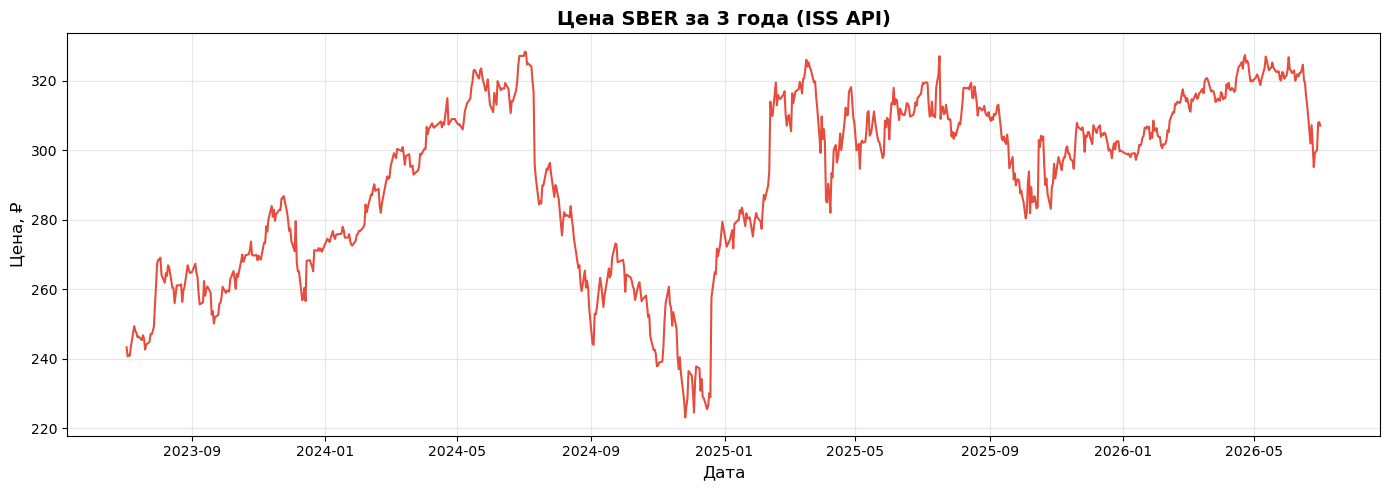

In [27]:

plt.figure(figsize=(14, 5))
plt.plot(df_prophet_3years['ds'], df_prophet_3years['y'], color='#e74c3c', linewidth=1.5)
plt.title(f'Цена SBER за 3 года (ISS API)', fontsize=14, fontweight='bold')
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Цена, ₽', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Разделение на train/test

Train: 695 строк (2023-07-03 — 2025-12-21)
Test:  174 строк (2025-12-22 — 2026-07-01)


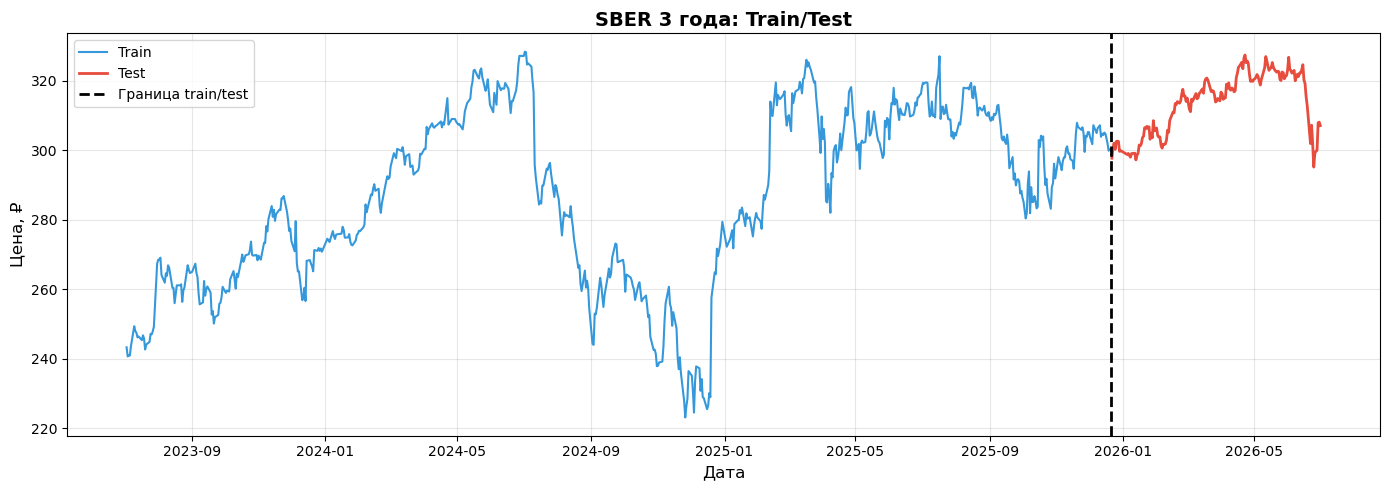

In [28]:
split_idx = int(len(df_prophet_3years) * 0.8)

df_train_3y = df_prophet_3years.iloc[:split_idx].copy()
df_test_3y = df_prophet_3years.iloc[split_idx:].copy()


print(f"Train: {len(df_train_3y)} строк ({df_train_3y['ds'].min().date()} — {df_train_3y['ds'].max().date()})")
print(f"Test:  {len(df_test_3y)} строк ({df_test_3y['ds'].min().date()} — {df_test_3y['ds'].max().date()})")

# Визуализация
plt.figure(figsize=(14, 5))
plt.plot(df_train_3y['ds'], df_train_3y['y'], label='Train', color='#3498db', linewidth=1.5)
plt.plot(df_test_3y['ds'], df_test_3y['y'], label='Test', color='#e74c3c', linewidth=2)
plt.axvline(x=df_train_3y['ds'].max(), color='black', linestyle='--', linewidth=2, label='Граница train/test')
plt.title('SBER 3 года: Train/Test', fontsize=14, fontweight='bold')
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Цена, ₽', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Сохраняем
df_train_3y.to_csv('sber_train_3y.csv', index=False)
df_test_3y.to_csv('sber_test_3y.csv', index=False)


## baseline

In [29]:
print(f"Обучаем Prophet на 3-летних данных (baseline)...")
print(f"Train: {len(df_train_3y)} строк")
print(f"Test: {len(df_test_3y)} строк")

# Инициализируем модель
model_3y = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.05
)

# Обучаем
model_3y.fit(df_train_3y)
print(" Модель обучена")

# Создаём датафрейм для прогноза
future_3y = model_3y.make_future_dataframe(periods=len(df_test_3y), freq='D')

# Делаем прогноз
print("Делаем прогноз...")
forecast_3y = model_3y.predict(future_3y)

# Берём только прогнозы на test период
forecast_test_3y = forecast_3y[forecast_3y['ds'] >= df_test_3y['ds'].min()].copy()

print(f" Прогноз сделан: {len(forecast_test_3y)} строк")

INFO:cmdstanpy:start chain 1


Обучаем Prophet на 3-летних данных (baseline)...
Train: 695 строк
Test: 174 строк


INFO:cmdstanpy:finish chain 1


 Модель обучена
Делаем прогноз...
 Прогноз сделан: 174 строк


## Метрики baseline

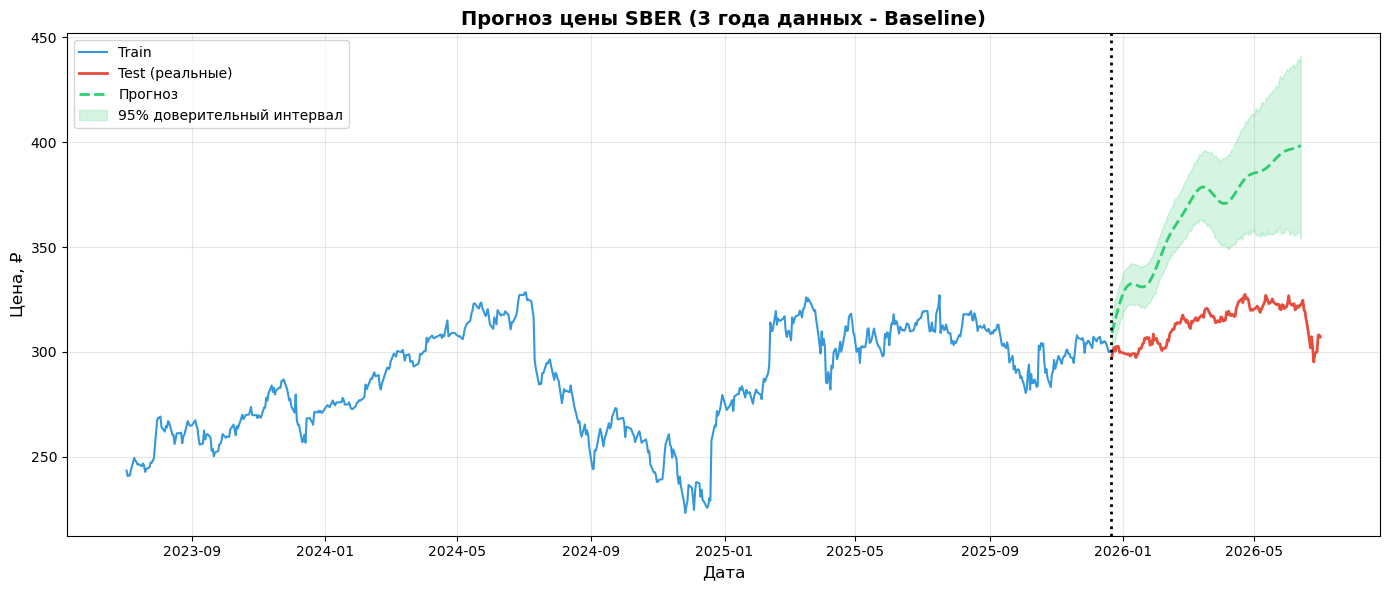


📊 МЕТРИКИ КАЧЕСТВА МОДЕЛИ (Baseline)
MAE:  51.85 ₽
RMSE: 55.24 ₽
MAPE: 16.45%


In [30]:
# Сравнение
comparison_3y = pd.DataFrame({
    'ds': df_test_3y['ds'].values,
    'y_true': df_test_3y['y'].values,
    'y_pred': forecast_test_3y['yhat'].values
})

# Визуализация
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df_train_3y['ds'], df_train_3y['y'], label='Train', color='#3498db', linewidth=1.5)
ax.plot(df_test_3y['ds'], df_test_3y['y'], label='Test (реальные)', color='#e74c3c', linewidth=2)
ax.plot(forecast_test_3y['ds'], forecast_test_3y['yhat'], label='Прогноз', color='#2ecc71', linewidth=2, linestyle='--')
ax.fill_between(forecast_test_3y['ds'], 
                forecast_test_3y['yhat_lower'], 
                forecast_test_3y['yhat_upper'], 
                alpha=0.2, color='#2ecc71', label='95% доверительный интервал')
ax.axvline(x=df_train_3y['ds'].max(), color='black', linestyle=':', linewidth=2)
ax.set_title('Прогноз цены SBER (3 года данных - Baseline)', fontsize=14, fontweight='bold')
ax.set_xlabel('Дата', fontsize=12)
ax.set_ylabel('Цена, ₽', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Метрики
mae = mean_absolute_error(comparison_3y['y_true'], comparison_3y['y_pred'])
rmse = np.sqrt(mean_squared_error(comparison_3y['y_true'], comparison_3y['y_pred']))
mape = mean_absolute_percentage_error(comparison_3y['y_true'], comparison_3y['y_pred']) * 100

print("\n" + "=" * 60)
print("📊 МЕТРИКИ КАЧЕСТВА МОДЕЛИ (Baseline)")
print("=" * 60)
print(f"MAE:  {mae:.2f} ₽")
print(f"RMSE: {rmse:.2f} ₽")
print(f"MAPE: {mape:.2f}%")
print("=" * 60)

# Сохраняем
comparison_3y.to_csv('comparison_3y.csv', index=False)
with open('baseline_metrics.json', 'w', encoding='utf-8') as f:
    json.dump({'MAE': mae, 'RMSE': rmse, 'MAPE': mape}, f, indent=2)
with open('prophet_model_baseline.pkl', 'wb') as f:
    pickle.dump(model_3y, f)


## Grid Search

In [31]:

param_grid = {
    'changepoint_prior_scale': [0.001, 0.01, 0.05, 0.1, 0.5],
    'seasonality_prior_scale': [0.01, 0.1, 1.0, 10.0],
    'holidays_prior_scale': [0.01, 0.1, 1.0, 10.0]
}

# Генерируем все комбинации
keys, values = zip(*param_grid.items())
param_combinations = [dict(zip(keys, v)) for v in product(*values)]

print(f"Всего комбинаций для проверки: {len(param_combinations)}")

# Функция для быстрой оценки модели
def evaluate_prophet(params, train_df, test_df):
    """Обучает модель с заданными параметрами и возвращает метрики"""
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        **params
    )
    model.fit(train_df)
    
    future = model.make_future_dataframe(periods=len(test_df), freq='D')
    forecast = model.predict(future)
    
    forecast_test = forecast[forecast['ds'] >= test_df['ds'].min()]
    
    y_true = test_df['y'].values
    y_pred = forecast_test['yhat'].values
    
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}



Всего комбинаций для проверки: 80


In [32]:
# Перебираем параметры
results = []


for i, params in enumerate(param_combinations):
    try:
        metrics = evaluate_prophet(params, df_train_3y, df_test_3y)
        results.append({**params, **metrics})
        
        if (i + 1) % 10 == 0:
            print(f"  Проверено {i + 1}/{len(param_combinations)} комбинаций...")
    except Exception as e:
        print(f"  ❌ Ошибка с параметрами {params}: {e}")

# Создаём DataFrame с результатами
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('MAPE')

print(f"\n✅ Поиск завершён")


INFO:cmdstanpy:start chain 1
INFO:cmdstanpy:finish chain 1
INFO:cmdstanpy:start chain 1
INFO:cmdstanpy:finish chain 1
INFO:cmdstanpy:start chain 1
INFO:cmdstanpy:finish chain 1
INFO:cmdstanpy:start chain 1
INFO:cmdstanpy:finish chain 1
INFO:cmdstanpy:start chain 1
INFO:cmdstanpy:finish chain 1
INFO:cmdstanpy:start chain 1
INFO:cmdstanpy:finish chain 1
INFO:cmdstanpy:start chain 1
INFO:cmdstanpy:finish chain 1
INFO:cmdstanpy:start chain 1
INFO:cmdstanpy:finish chain 1
INFO:cmdstanpy:start chain 1
INFO:cmdstanpy:finish chain 1
INFO:cmdstanpy:start chain 1
INFO:cmdstanpy:finish chain 1
INFO:cmdstanpy:start chain 1
INFO:cmdstanpy:finish chain 1
INFO:cmdstanpy:start chain 1
INFO:cmdstanpy:finish chain 1


  Проверено 10/80 комбинаций...


INFO:cmdstanpy:start chain 1
INFO:cmdstanpy:finish chain 1
INFO:cmdstanpy:start chain 1
INFO:cmdstanpy:finish chain 1
INFO:cmdstanpy:start chain 1
INFO:cmdstanpy:finish chain 1
INFO:cmdstanpy:start chain 1
INFO:cmdstanpy:finish chain 1
INFO:cmdstanpy:start chain 1
INFO:cmdstanpy:finish chain 1
INFO:cmdstanpy:start chain 1
INFO:cmdstanpy:finish chain 1
INFO:cmdstanpy:start chain 1
INFO:cmdstanpy:finish chain 1
INFO:cmdstanpy:start chain 1
INFO:cmdstanpy:finish chain 1
INFO:cmdstanpy:start chain 1
INFO:cmdstanpy:finish chain 1
INFO:cmdstanpy:start chain 1
INFO:cmdstanpy:finish chain 1


  Проверено 20/80 комбинаций...


INFO:cmdstanpy:start chain 1
INFO:cmdstanpy:finish chain 1
INFO:cmdstanpy:start chain 1
INFO:cmdstanpy:finish chain 1
INFO:cmdstanpy:start chain 1
INFO:cmdstanpy:finish chain 1
INFO:cmdstanpy:start chain 1
INFO:cmdstanpy:finish chain 1
INFO:cmdstanpy:start chain 1
INFO:cmdstanpy:finish chain 1
INFO:cmdstanpy:start chain 1
INFO:cmdstanpy:finish chain 1
INFO:cmdstanpy:start chain 1
INFO:cmdstanpy:finish chain 1
INFO:cmdstanpy:start chain 1
INFO:cmdstanpy:finish chain 1
INFO:cmdstanpy:start chain 1
INFO:cmdstanpy:finish chain 1
INFO:cmdstanpy:start chain 1
INFO:cmdstanpy:finish chain 1


...

  Проверено 60/80 комбинаций...


INFO:cmdstanpy:start chain 1
INFO:cmdstanpy:finish chain 1
INFO:cmdstanpy:start chain 1
INFO:cmdstanpy:finish chain 1
INFO:cmdstanpy:start chain 1
INFO:cmdstanpy:finish chain 1
INFO:cmdstanpy:start chain 1
INFO:cmdstanpy:finish chain 1
INFO:cmdstanpy:start chain 1
INFO:cmdstanpy:finish chain 1
INFO:cmdstanpy:start chain 1
INFO:cmdstanpy:finish chain 1
INFO:cmdstanpy:start chain 1
INFO:cmdstanpy:finish chain 1
INFO:cmdstanpy:start chain 1
INFO:cmdstanpy:finish chain 1
INFO:cmdstanpy:start chain 1
INFO:cmdstanpy:finish chain 1
INFO:cmdstanpy:start chain 1
INFO:cmdstanpy:finish chain 1


  Проверено 70/80 комбинаций...


INFO:cmdstanpy:start chain 1
INFO:cmdstanpy:finish chain 1
INFO:cmdstanpy:start chain 1
INFO:cmdstanpy:finish chain 1
INFO:cmdstanpy:start chain 1
INFO:cmdstanpy:finish chain 1
INFO:cmdstanpy:start chain 1
INFO:cmdstanpy:finish chain 1
INFO:cmdstanpy:start chain 1
INFO:cmdstanpy:finish chain 1
INFO:cmdstanpy:start chain 1
INFO:cmdstanpy:finish chain 1
INFO:cmdstanpy:start chain 1
INFO:cmdstanpy:finish chain 1
INFO:cmdstanpy:start chain 1
INFO:cmdstanpy:finish chain 1
INFO:cmdstanpy:start chain 1
INFO:cmdstanpy:finish chain 1


  Проверено 80/80 комбинаций...

✅ Поиск завершён


In [33]:
print(f"\nТоп-5 лучших комбинаций по MAPE:")
display(results_df.head())


Топ-5 лучших комбинаций по MAPE:


,changepoint_prior_scale,seasonality_prior_scale,holidays_prior_scale,MAE,RMSE,MAPE
65,0.500,0.01,0.10,11.496892,13.991051,3.718001
66,0.500,0.01,1.00,11.496892,13.991051,3.718001
67,0.500,0.01,10.00,11.496892,13.991051,3.718001
64,0.500,0.01,0.01,11.496892,13.991051,3.718001
4,0.001,0.10,0.01,11.880215,14.723144,3.784347


## Обучение лучшей модели

In [34]:
# Берём лучшие параметры
best_params = results_df.iloc[0][['changepoint_prior_scale', 'seasonality_prior_scale', 'holidays_prior_scale']].to_dict()

print("Лучшие параметры:")
for key, value in best_params.items():
    print(f"  {key}: {value}")

print(f"\nЛучшие метрики:")
print(f"  MAE:  {results_df.iloc[0]['MAE']:.2f} ₽")
print(f"  RMSE: {results_df.iloc[0]['RMSE']:.2f} ₽")
print(f"  MAPE: {results_df.iloc[0]['MAPE']:.2f}%")

# Обучаем финальную модель с лучшими параметрами
print(f"\nОбучаем финальную модель с лучшими параметрами...")

model_best = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    **best_params
)

model_best.fit(df_train_3y)


# Прогноз
future_best = model_best.make_future_dataframe(periods=len(df_test_3y), freq='D')
forecast_best = model_best.predict(future_best)
forecast_test_best = forecast_best[forecast_best['ds'] >= df_test_3y['ds'].min()].copy()


INFO:cmdstanpy:start chain 1


Лучшие параметры:
  changepoint_prior_scale: 0.5
  seasonality_prior_scale: 0.01
  holidays_prior_scale: 0.1

Лучшие метрики:
  MAE:  11.50 ₽
  RMSE: 13.99 ₽
  MAPE: 3.72%

Обучаем финальную модель с лучшими параметрами...


INFO:cmdstanpy:finish chain 1


## Сравнение

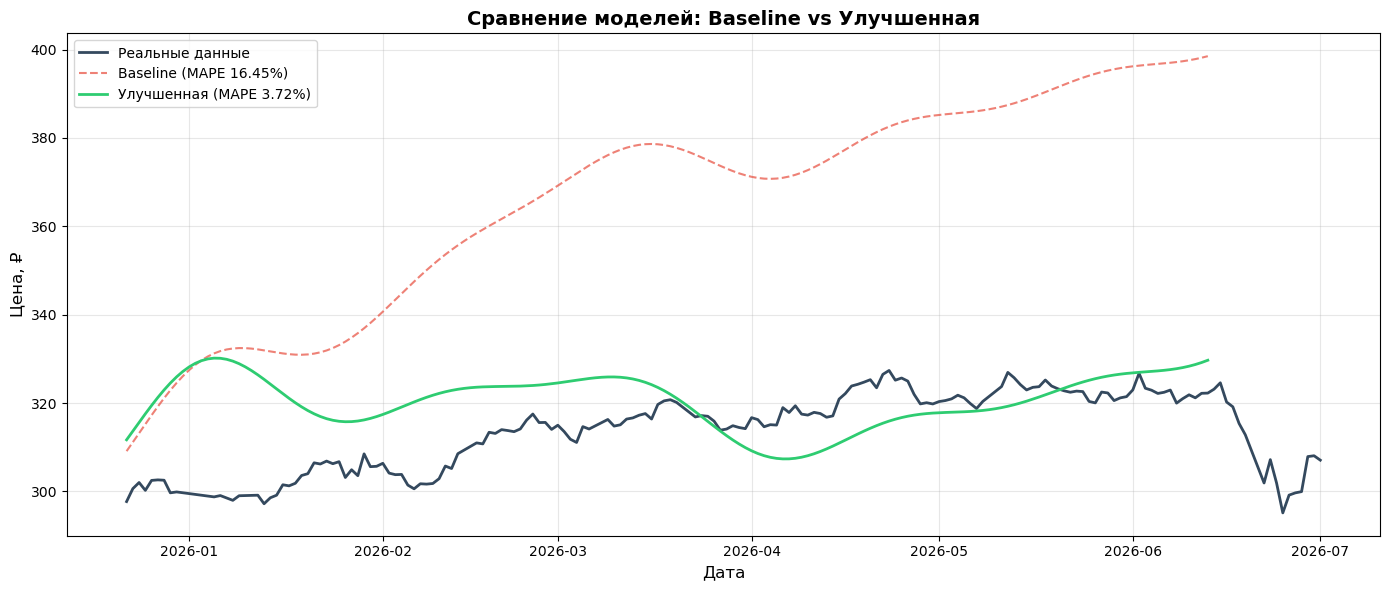


СРАВНЕНИЕ МОДЕЛЕЙ
Метрика    Baseline        Улучшенная      Улучшение      
------------------------------------------------------------
MAE        51.85           11.50           77.82          %
RMSE       55.24           13.99           74.67          %
MAPE       16.45          % 3.72           % 77.40          %
✅ Лучшая модель сохранена в 'prophet_model_best.pkl'
✅ Метрики сохранены в 'metrics_comparison.json'
✅ Результаты grid search сохранены в 'grid_search_results.csv'


In [35]:
comparison_best = pd.DataFrame({
    'ds': df_test_3y['ds'].values,
    'y_true': df_test_3y['y'].values,
    'y_pred_baseline': forecast_test_3y['yhat'].values,
    'y_pred_best': forecast_test_best['yhat'].values
})

# Метрики для лучшей модели
mae_best = mean_absolute_error(comparison_best['y_true'], comparison_best['y_pred_best'])
rmse_best = np.sqrt(mean_squared_error(comparison_best['y_true'], comparison_best['y_pred_best']))
mape_best = mean_absolute_percentage_error(comparison_best['y_true'], comparison_best['y_pred_best']) * 100

# Визуализация сравнения
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df_test_3y['ds'], df_test_3y['y'], label='Реальные данные', color='#34495e', linewidth=2)
ax.plot(forecast_test_3y['ds'], forecast_test_3y['yhat'], label=f'Baseline (MAPE {mape:.2f}%)', 
        color='#e74c3c', linewidth=1.5, linestyle='--', alpha=0.7)
ax.plot(forecast_test_best['ds'], forecast_test_best['yhat'], label=f'Улучшенная (MAPE {mape_best:.2f}%)', 
        color='#2ecc71', linewidth=2)
ax.set_title('Сравнение моделей: Baseline vs Улучшенная', fontsize=14, fontweight='bold')
ax.set_xlabel('Дата', fontsize=12)
ax.set_ylabel('Цена, ₽', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Таблица сравнения
print("\n" + "=" * 60)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("=" * 60)
print(f"{'Метрика':<10} {'Baseline':<15} {'Улучшенная':<15} {'Улучшение':<15}")
print("-" * 60)
print(f"{'MAE':<10} {mae:<15.2f} {mae_best:<15.2f} {((mae - mae_best) / mae * 100):<15.2f}%")
print(f"{'RMSE':<10} {rmse:<15.2f} {rmse_best:<15.2f} {((rmse - rmse_best) / rmse * 100):<15.2f}%")
print(f"{'MAPE':<10} {mape:<15.2f}% {mape_best:<15.2f}% {((mape - mape_best) / mape * 100):<15.2f}%")
print("=" * 60)

# Сохраняем лучшую модель
with open('prophet_model_best.pkl', 'wb') as f:
    pickle.dump(model_best, f)
print("✅ Лучшая модель сохранена в 'prophet_model_best.pkl'")

# Сохраняем метрики
metrics_comparison = {
    'baseline': {'MAE': mae, 'RMSE': rmse, 'MAPE': mape},
    'best': {'MAE': mae_best, 'RMSE': rmse_best, 'MAPE': mape_best},
    'best_params': best_params
}

with open('metrics_comparison.json', 'w', encoding='utf-8') as f:
    json.dump(metrics_comparison, f, ensure_ascii=False, indent=2)
print("✅ Метрики сохранены в 'metrics_comparison.json'")

# Сохраняем результаты grid search
results_df.to_csv('grid_search_results.csv', index=False)
print("✅ Результаты grid search сохранены в 'grid_search_results.csv'")

## обёртка для MLFlow

In [36]:


class StockForecastModel(mlflow.pyfunc.PythonModel):
    """
    Класс-обёртка для модели прогнозирования акций.
    Наследует mlflow.pyfunc.PythonModel для корректной работы с MLFlow.
    """
    
    def load_context(self, context):
        """Загружает модель и необходимые артефакты из контекста."""
        with open(context.artifacts["model"], "rb") as f:
            self.model = pickle.load(f)
        
        with open(context.artifacts["last_date"], "rb") as f:
            self.last_date = pickle.load(f)
        
        print(f"   Модель загружена")
        print(f"   Последний день обучения: {self.last_date}")
    
    def predict(self, context, model_input):
        """Делает прогноз на заданный период."""
        if 'days' in model_input.columns:
            days = int(model_input['days'].iloc[0])
            start_date = self.last_date + timedelta(days=1)
        elif 'start_date' in model_input.columns:
            start_date = pd.to_datetime(model_input['start_date'].iloc[0])
            if 'days' in model_input.columns:
                days = int(model_input['days'].iloc[0])
            else:
                days = 30
        else:
            days = 30
            start_date = self.last_date + timedelta(days=1)
        
        future = self.model.make_future_dataframe(periods=days, freq='D')
        forecast = self.model.predict(future)
        forecast_future = forecast[forecast['ds'] >= start_date].copy()
        
        result = forecast_future[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
        result = result.rename(columns={
            'yhat': 'prediction',
            'yhat_lower': 'prediction_lower',
            'yhat_upper': 'prediction_upper'
        })
        
        return result


C:\Users\sava\AppData\Roaming\Python\Python313\site-packages\mlflow\pyfunc\utils\data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


## Тестирование обёртки

In [37]:
# Сохраняем последнюю дату из train
last_date = df_train_3y['ds'].max()

# Сохраняем модель и метаданные для тестирования
with open('test_model.pkl', 'wb') as f:
    pickle.dump(model_best, f)

with open('test_last_date.pkl', 'wb') as f:
    pickle.dump(last_date, f)

print(f"Последняя дата обучения: {last_date.date()}")

# Создаём артефакты для тестирования
artifacts = {
    "model": "test_model.pkl",
    "last_date": "test_last_date.pkl"
}

# Инициализируем обёртку
model_wrapper = StockForecastModel()

# Создаём mock контекст для локального тестирования
class MockContext:
    def __init__(self, artifacts):
        self.artifacts = artifacts

mock_context = MockContext(artifacts)

# Загружаем модель
model_wrapper.load_context(mock_context)

# Тестируем прогноз на 7 дней
print("\n Тест прогноза на 7 дней:")
test_input = pd.DataFrame({'days': [7]})
prediction = model_wrapper.predict(mock_context, test_input)
display(prediction)

# Тестируем прогноз на 30 дней
print("\n Тест прогноза на 30 дней:")
test_input = pd.DataFrame({'days': [30]})
prediction_30 = model_wrapper.predict(mock_context, test_input)
print(f"Получено прогнозов: {len(prediction_30)}")
print(f"Диапазон: {prediction_30['ds'].min().date()} — {prediction_30['ds'].max().date()}")
display(prediction_30.head())

Последняя дата обучения: 2025-12-21
   Модель загружена
   Последний день обучения: 2025-12-21 00:00:00

 Тест прогноза на 7 дней:


,ds,prediction,prediction_lower,prediction_upper
695,2025-12-22,311.693847,304.216620,319.147887
696,2025-12-23,313.657728,306.197969,321.281000
697,2025-12-24,315.629253,308.140093,322.757163
698,2025-12-25,317.577269,310.981986,324.646554
699,2025-12-26,319.471017,312.643086,326.667393
700,2025-12-27,321.280814,313.949940,328.734119
701,2025-12-28,322.978717,315.796728,329.599283



 Тест прогноза на 30 дней:
Получено прогнозов: 30
Диапазон: 2025-12-22 — 2026-01-20


,ds,prediction,prediction_lower,prediction_upper
695,2025-12-22,311.693847,304.514345,318.598677
696,2025-12-23,313.657728,306.302312,320.524151
697,2025-12-24,315.629253,308.655622,323.019395
698,2025-12-25,317.577269,310.406611,324.852517
699,2025-12-26,319.471017,312.298577,326.819465


## Сохранение артефактов для MLFlow

In [38]:

# Создаём папку для артефактов
os.makedirs('mlflow_artifacts', exist_ok=True)

# Сохраняем модель
with open('mlflow_artifacts/model.pkl', 'wb') as f:
    pickle.dump(model_best, f)

# Сохраняем последнюю дату
with open('mlflow_artifacts/last_date.pkl', 'wb') as f:
    pickle.dump(last_date, f)

# Сохраняем метаданные модели
model_metadata = {
    'model_type': 'Prophet',
    'ticker': 'SBER',
    'training_data_range': {
        'start': df_train_3y['ds'].min().strftime('%Y-%m-%d'),
        'end': df_train_3y['ds'].max().strftime('%Y-%m-%d')
    },
    'training_samples': len(df_train_3y),
    'best_params': best_params,
    'metrics': {
        'MAE': mae_best,
        'RMSE': rmse_best,
        'MAPE': mape_best
    },
    'last_training_date': last_date.strftime('%Y-%m-%d')
}

with open('mlflow_artifacts/model_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(model_metadata, f, ensure_ascii=False, indent=2)

print(" Артефакты сохранены в 'mlflow_artifacts/'")
print("\nСодержимое папки:")
for file in os.listdir('mlflow_artifacts'):
    size = os.path.getsize(f'mlflow_artifacts/{file}')
    print(f"  - {file} ({size} bytes)")

print(f"\n Метаданные модели:")
print(json.dumps(model_metadata, ensure_ascii=False, indent=2))

 Артефакты сохранены в 'mlflow_artifacts/'

Содержимое папки:
  - last_date.pkl (88 bytes)
  - model.pkl (62276 bytes)
  - model_metadata.json (458 bytes)

 Метаданные модели:
{
  "model_type": "Prophet",
  "ticker": "SBER",
  "training_data_range": {
    "start": "2023-07-03",
    "end": "2025-12-21"
  },
  "training_samples": 695,
  "best_params": {
    "changepoint_prior_scale": 0.5,
    "seasonality_prior_scale": 0.01,
    "holidays_prior_scale": 0.1
  },
  "metrics": {
    "MAE": 11.49689208545616,
    "RMSE": 13.991050574550732,
    "MAPE": 3.7180013246371297
  },
  "last_training_date": "2025-12-21"
}
